In [1]:
from PIL import Image
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt


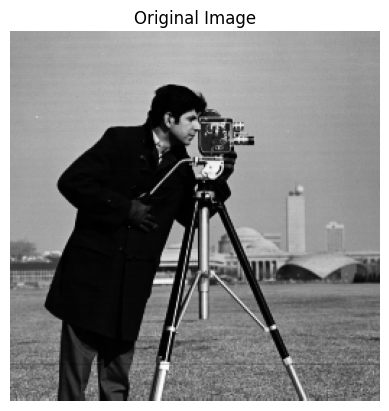

In [2]:
# 載入影像並轉為灰階
image_path = "/content/drive/MyDrive/Cameraman.bmp"
img = Image.open(image_path).convert("L")
img_np = np.array(img)

# 顯示原始影像
plt.imshow(img_np, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


In [3]:
def dct2(block):
    return cv2.dct(block.astype(np.float32))

def idct2(block):
    return cv2.idct(block.astype(np.float32))


In [4]:
def dct_compression(img, quality=50):
    start_time = time.time()
    h, w = img.shape
    block_size = 8
    quant_table = np.ones((8, 8)) * (100 - quality + 1)

    compressed = np.zeros_like(img, dtype=np.float32)
    nonzero_before = 0
    nonzero_after = 0

    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = img[i:i+block_size, j:j+block_size]
            dct_block = dct2(block)
            nonzero_before += np.count_nonzero(dct_block)

            quant_block = np.round(dct_block / quant_table)
            nonzero_after += np.count_nonzero(quant_block)

            dequant_block = quant_block * quant_table
            idct_block = idct2(dequant_block)

            compressed[i:i+block_size, j:j+block_size] = idct_block

    elapsed_time = time.time() - start_time
    compressed = np.clip(compressed, 0, 255).astype(np.uint8)
    compression_ratio = nonzero_before / nonzero_after if nonzero_after != 0 else 1

    return compressed, compression_ratio, elapsed_time


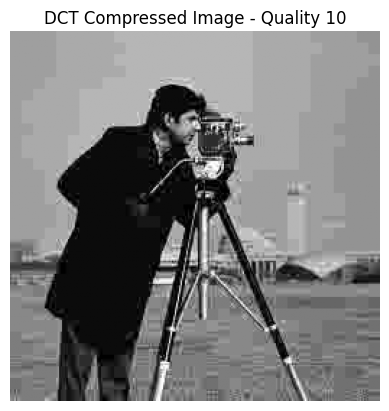

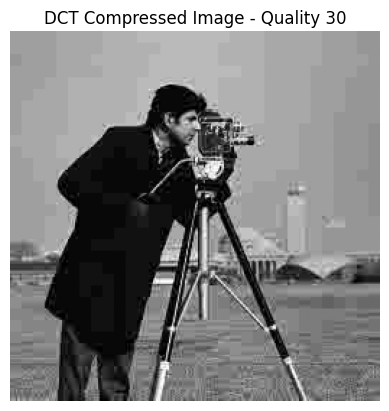

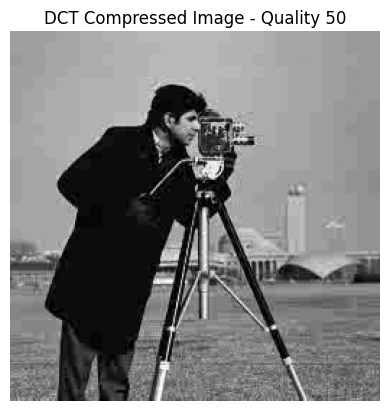

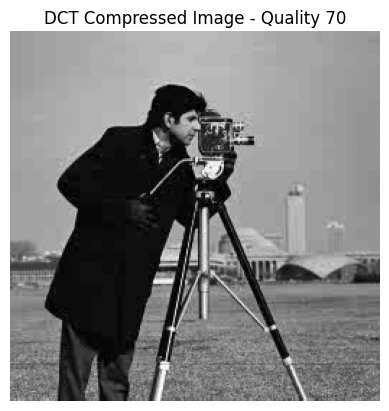

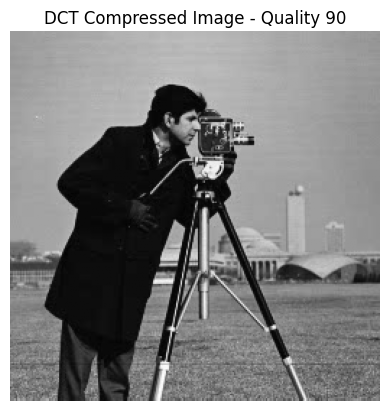

Quality | Compression Ratio | Execution Time (s)
10      |             18.37 |            0.0462
30      |             14.40 |            0.0180
50      |             10.42 |            0.0186
70      |              6.49 |            0.0173
90      |              3.23 |            0.0192


In [5]:
quality_settings = [10, 30, 50, 70, 90]
results = []

for quality in quality_settings:
    compressed_img, ratio, elapsed = dct_compression(img_np, quality)
    results.append((quality, ratio, elapsed))

    plt.imshow(compressed_img, cmap='gray')
    plt.title(f"DCT Compressed Image - Quality {quality}")
    plt.axis('off')
    plt.show()

# 印出總結
print("Quality | Compression Ratio | Execution Time (s)")
for quality, ratio, elapsed in results:
    print(f"{quality:<7} | {ratio:>17.2f} | {elapsed:>17.4f}")


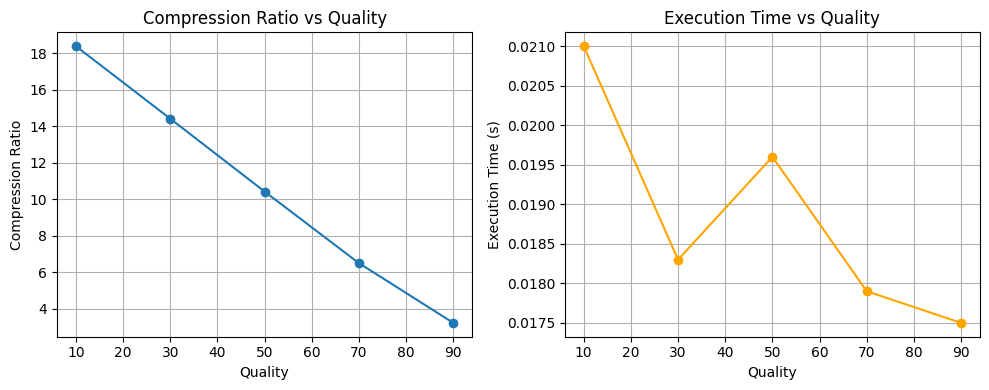

In [6]:
import matplotlib.pyplot as plt

# 資料
qualities = [10, 30, 50, 70, 90]
compression_ratios = [18.38, 14.41, 10.42, 6.50, 3.23]
execution_times = [0.0210, 0.0183, 0.0196, 0.0179, 0.0175]

# 建立比較圖表
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(qualities, compression_ratios, marker='o')
plt.title("Compression Ratio vs Quality")
plt.xlabel("Quality")
plt.ylabel("Compression Ratio")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(qualities, execution_times, marker='o', color='orange')
plt.title("Execution Time vs Quality")
plt.xlabel("Quality")
plt.ylabel("Execution Time (s)")
plt.grid(True)

# 儲存圖檔
plt.tight_layout()
plt.savefig("DCT_Comparison_Chart.png")
plt.show()
